# 03 — Baseline Results (Loaded from Saved)
Load pre-computed ARIMA & Random Forest results from JSON files.
**No training** — just loads results and visualizes.

In [1]:
import sys, os, json
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src import config
plt.style.use('seaborn-v0_8-darkgrid')

## 1. Load Saved Baseline Results

In [2]:
metrics_dir = '../results/metrics'
baseline_results = {}

for dataset in ['METR-LA', 'PEMS-BAY']:
    path = os.path.join(metrics_dir, f'{dataset}_baselines_results.json')
    if os.path.exists(path):
        with open(path) as f:
            baseline_results[dataset] = json.load(f)
        print(f"Loaded {dataset}: {list(baseline_results[dataset].keys())}")
    else:
        print(f"Not found: {path}")

Loaded METR-LA: ['ARIMA', 'RandomForest', 'LSTM']
Loaded PEMS-BAY: ['ARIMA', 'RandomForest', 'LSTM']


## 2. Results Tables

In [3]:
for dataset, results in baseline_results.items():
    print(f"\n{'='*60}")
    print(f"  BASELINE RESULTS — {dataset}")
    print(f"{'='*60}")
    print(f"  {'Model':<20} {'Horizon':<10} {'MAE':>8} {'RMSE':>8} {'MAPE(%)':>8}")
    print(f"  {'-'*56}")
    for model, r in results.items():
        for h in ['15min', '30min', '60min']:
            if h in r:
                print(f"  {model:<20} {h:<10} {r[h]['MAE']:>8.4f} {r[h]['RMSE']:>8.4f} {r[h]['MAPE']:>8.2f}")


  BASELINE RESULTS — METR-LA
  Model                Horizon         MAE     RMSE  MAPE(%)
  --------------------------------------------------------
  ARIMA                15min        3.2883   6.4587     8.32
  ARIMA                30min        3.8798   7.7344    10.23
  ARIMA                60min        4.8878   9.6374    13.38
  RandomForest         15min        3.0466   5.8271     8.31
  RandomForest         30min        3.7479   7.1283    10.83
  RandomForest         60min        4.7621   8.6777    14.47
  LSTM                 15min        3.8433   6.7368    10.73
  LSTM                 30min        3.9097   6.8741    10.90
  LSTM                 60min        4.1370   7.2604    11.72

  BASELINE RESULTS — PEMS-BAY
  Model                Horizon         MAE     RMSE  MAPE(%)
  --------------------------------------------------------
  ARIMA                15min        1.7342   3.9618     3.63
  ARIMA                30min        2.2722   5.2491     4.94
  ARIMA                60min

## 3. Baseline Comparison Chart

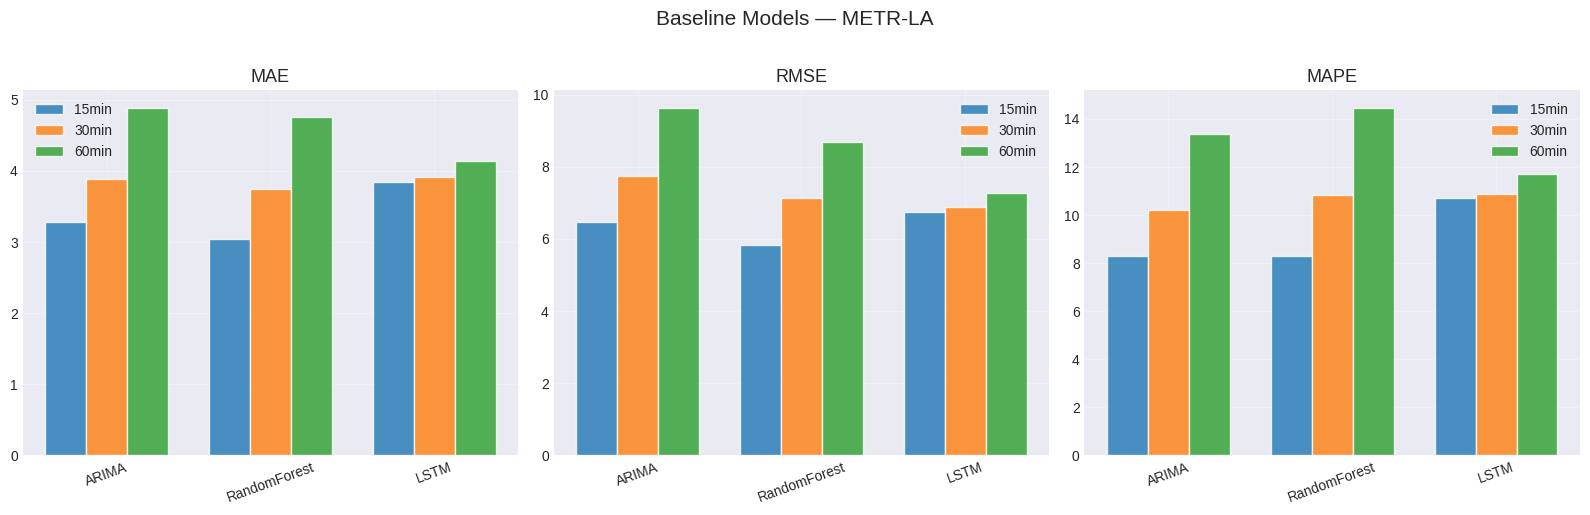

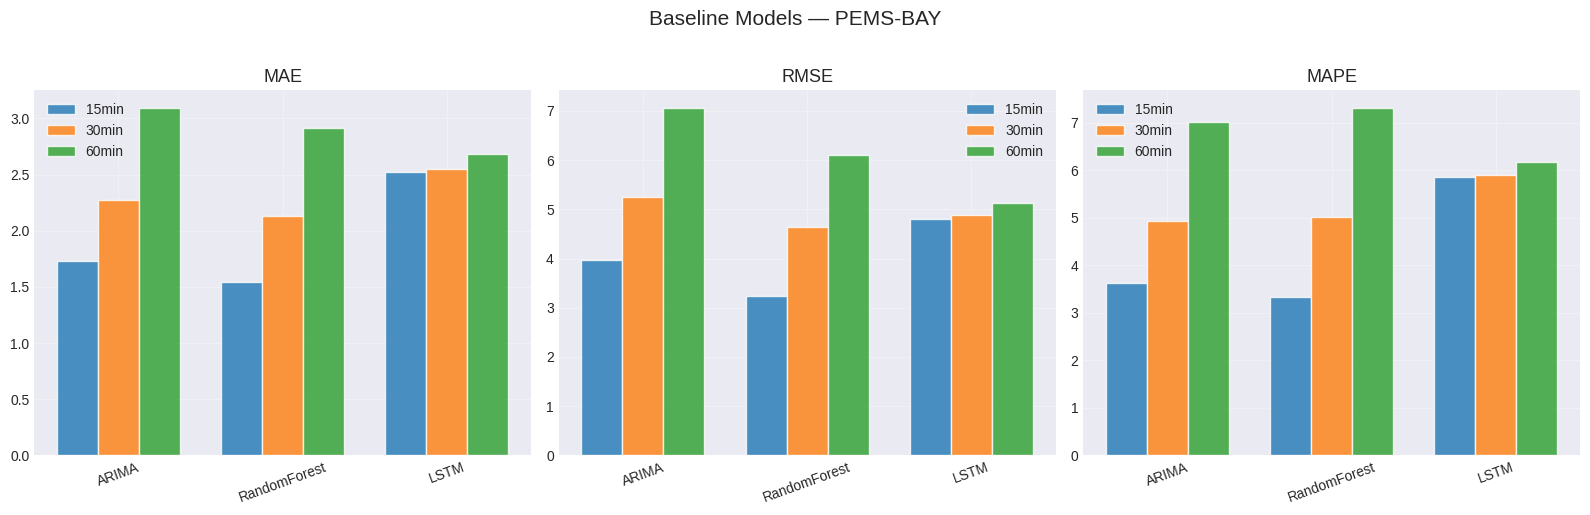

In [4]:
colors = {'ARIMA':'#e74c3c', 'RandomForest':'#e67e22', 'HistAvg':'#95a5a6', 'LastValue':'#bdc3c7'}

for dataset, results in baseline_results.items():
    models = list(results.keys())
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for idx, metric in enumerate(['MAE', 'RMSE', 'MAPE']):
        for h_idx, horizon in enumerate(['15min', '30min', '60min']):
            vals = [results[m][horizon][metric] for m in models if horizon in results[m]]
            names = [m for m in models if horizon in results[m]]
            x = np.arange(len(names))
            w = 0.25
            bars = axes[idx].bar(x + h_idx*w, vals, w, label=horizon,
                                alpha=0.8, edgecolor='white')
        axes[idx].set_xticks(x + w); axes[idx].set_xticklabels(names, rotation=20)
        axes[idx].set_title(f'{metric}', fontsize=13); axes[idx].legend(); axes[idx].grid(True, alpha=0.3)
    plt.suptitle(f'Baseline Models — {dataset}', fontsize=15, y=1.02)
    plt.tight_layout()
    plt.savefig(f'../results/plots/{dataset}_baselines_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4. Error Growth with Horizon

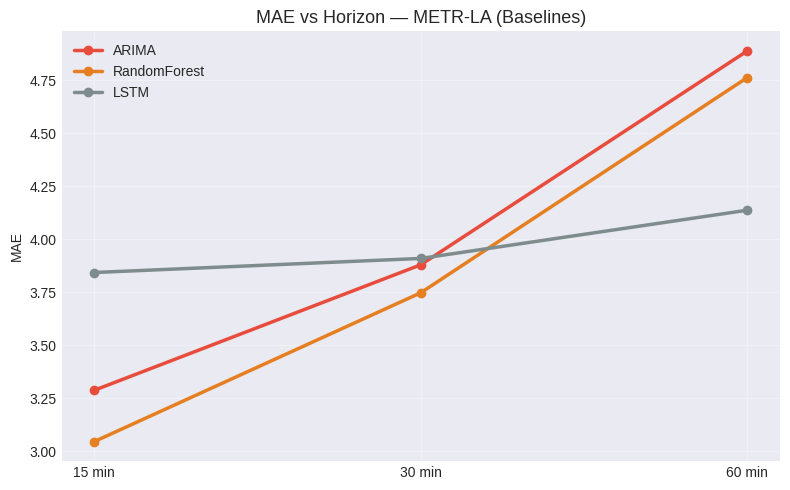

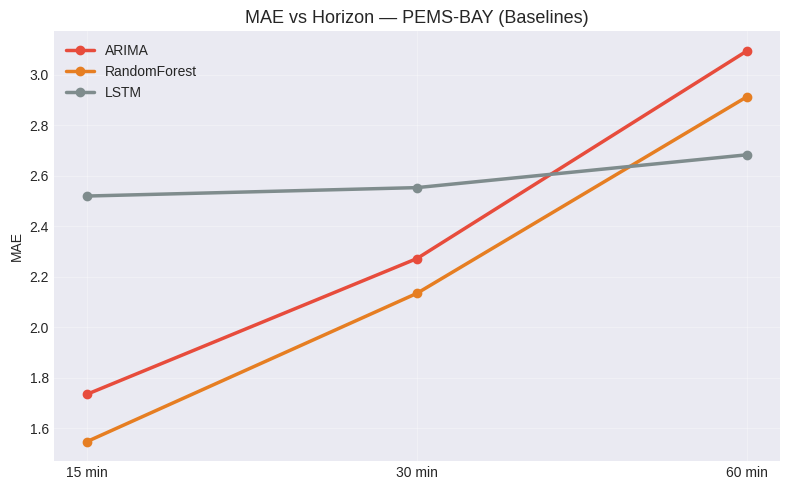

In [5]:
for dataset, results in baseline_results.items():
    fig, ax = plt.subplots(figsize=(8, 5))
    horizons = ['15min', '30min', '60min']
    for model in results:
        if all(h in results[model] for h in horizons):
            vals = [results[model][h]['MAE'] for h in horizons]
            c = colors.get(model, '#7f8c8d')
            ax.plot(['15 min','30 min','60 min'], vals, marker='o', linewidth=2.5,
                    label=model, color=c)
    ax.set_title(f'MAE vs Horizon — {dataset} (Baselines)', fontsize=13)
    ax.set_ylabel('MAE'); ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'../results/plots/{dataset}_baselines_horizon.png', dpi=150, bbox_inches='tight')
    plt.show()